## Dataset Preparation and Preprocessing for Waste Classification

This notebook prepares the Helene waste dataset for machine learning model training. The process includes loading labeled waste images, creating standardized category mappings, and organizing the data into train/validation/test splits while maintaining class distribution. The resulting structured dataset enables efficient training and evaluation of the waste classification chatbot system.

### 1. Setup and Library Imports

In [1]:
import shutil
from pathlib import Path
import pandas as pd
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import sys

### 2. Configuration Setup

This code adds the project's config directory to the Python path and imports the dataset file paths from the configuration file. It sets up three main path variables: SOURCE (original dataset), OUTPUT (processed data destination), and excel_path (waste category labels file).

In [2]:
# Add config directory to Python path for importing project settings
project_root = Path(r"C:\Users\Lejlum\Documents\agentic_framework\ba_agentic_framework\waste_recycling_chatbot_pa2\config")
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

# Import dataset paths and configuration from config file
from config import WASTE_CHATBOT_DATASET, PROCESSED_NEW, WASTE_CHATBOT_EXCEL

# Set source dataset and output directories
SOURCE = WASTE_CHATBOT_DATASET          # Original dataset location
OUTPUT = PROCESSED_NEW                  # Processed dataset output location  
excel_path = WASTE_CHATBOT_EXCEL        # Excel file with waste category labels

print(f"Source dataset exists: {SOURCE.exists()}")
print(f"Labels file exists: {excel_path.exists()}")

Source dataset exists: True
Labels file exists: True


### 3. Data Loading and Exploration

The Excel file containing waste image labels and metadata is loaded into a pandas DataFrame. Column names are defined for processing - "ID" for image filenames and "Label" for waste categories. Basic dataset information including shape, column names, and sample rows are displayed to understand the data structure.

In [3]:
# Load Excel file containing image labels and metadata
df = pd.read_excel(excel_path) 

# Define column names for processing
id_col = "ID"           # Column containing image filenames/IDs
label_col = "Label"     # Column containing waste category labels

print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
print(df.head())

Dataset shape: (5795, 4)
Columns: ['ID', 'Label', 'Source', 'Prompt Cumo V1']

First few rows:
         ID              Label    Source  \
0  0001.jpg  Plastic,Aluminium  own work   
1  0002.jpg  Plastic,Aluminium  own work   
2  0003.jpg  Plastic,Aluminium  own work   
3  0004.jpg  Plastic,Aluminium  own work   
4  0005.jpg  Plastic,Aluminium  own work   

                                      Prompt Cumo V1  
0  This item consists of plastic and aluminium. T...  
1  This item consists of plastic and aluminium. T...  
2  This item consists of plastic and aluminium. T...  
3  This item consists of plastic and aluminium. T...  
4  This item consists of plastic and aluminium. T...  


### 4. Label Processing and Category Mapping

Unique waste categories are extracted from the dataset and sorted alphabetically. A mapping dictionary is created to convert original label names into standardized folder names by converting to lowercase and replacing spaces and commas with underscores. The output displays all detected categories with their standardized versions and shows the total number of waste categories found.

In [4]:
# Extract unique waste categories from dataset
labels = sorted(df[label_col].astype(str).str.strip().unique().tolist())

# Create mapping from original labels to standardized folder names
# Convert to lowercase and replace spaces/commas with underscores
MAPPING = {label: label.lower().replace(" ", "_").replace(",", "_") for label in labels}

print("Detected waste categories:")
for original, standardized in MAPPING.items():
    print(f"{original} -> {standardized}")

print(f"\nTotal number of categories: {len(MAPPING)}")

Detected waste categories:
Aluminium -> aluminium
Brown Glass -> brown_glass
Cardboard -> cardboard
Composite Carton -> composite_carton
Green Glass -> green_glass
Hazardous waste (Battery) -> hazardous_waste_(battery)
Metal -> metal
Organic waste -> organic_waste
PET -> pet
Paper -> paper
Plastic -> plastic
Plastic,Aluminium -> plastic_aluminium
Residual waste -> residual_waste
Rigid plastic container -> rigid_plastic_container
White Glass -> white_glass
White Glass,Metal -> white_glass_metal

Total number of categories: 16


### 5. Directory Structure Creation

A nested folder structure is created for the dataset organization. Three main directories (train, val, test) are generated, each containing subdirectories for every waste category. The `mkdir()` function with `parents=True` creates all necessary parent directories, while `exist_ok=True` prevents errors if directories already exist. The final structure follows the pattern: OUTPUT/split/category/ for organized model training.

In [5]:
# Create train/validation/test split directories
splits = ["train", "val", "test"]

# Create folder structure: OUTPUT/split/category/
for split in splits:
    for category in MAPPING.values():
        (OUTPUT / split / category).mkdir(parents=True, exist_ok=True)

print("Created directory structure:")
print(f"Base output directory: {OUTPUT}")
print(f"Splits: {splits}")
print(f"Categories per split: {len(MAPPING)}")

Created directory structure:
Base output directory: C:\Users\Lejlum\Documents\PA2_Recycling_Chatbot\data\processed_new\organized_dataset
Splits: ['train', 'val', 'test']
Categories per split: 16


### 6. Data Splitting Strategy

A stratified split is performed to maintain proportional class distribution across all subsets. The dataset is divided into 70% training, 15% validation, and 15% test data through two sequential splits. The `stratify` parameter ensures each waste category appears proportionally in all splits, while `random_state=42` guarantees reproducible results. Split statistics are displayed showing the number and percentage of images in each subset.

In [6]:
# Perform stratified split to maintain class distribution
# First split: 70% train, 30% temp (for val+test)
train_df, temp_df = train_test_split(
    df, 
    test_size=0.3, 
    stratify=df[label_col], 
    random_state=42
)

# Second split: Split temp into 15% val, 15% test
val_df, test_df = train_test_split(
    temp_df, 
    test_size=0.5, 
    stratify=temp_df[label_col], 
    random_state=42
)

# Store splits in dictionary for easy iteration
splits_data = {
    "train": train_df,
    "val": val_df,
    "test": test_df
}

# Display split statistics
print("Dataset split summary:")
for split_name, split_df in splits_data.items():
    print(f"{split_name}: {len(split_df)} images ({len(split_df)/len(df)*100:.1f}%)")

Dataset split summary:
train: 4056 images (70.0%)
val: 869 images (15.0%)
test: 870 images (15.0%)


### 7. File Copy Operations

Images are copied from the source directory to their designated split and category folders. For each dataset split, the process iterates through all assigned images with a progress bar display. Source image paths are constructed using the ID column, and missing files are skipped with a warning message. Target paths follow the structure OUTPUT/split/category/image_name, with shutil.copy2() preserving file metadata during the copy operation.

In [7]:
# Copy images to appropriate directories based on split and category
for split_name, split_df in splits_data.items():
    print(f"\nCopying {split_name} images...")
    
    for _, row in tqdm(split_df.iterrows(), total=len(split_df), desc=f"Processing {split_name}"):
        # Source image path
        src = SOURCE / row[id_col]
        
        # Skip if source image doesn't exist
        if not src.exists():
            print(f"Warning: Image {src.name} not found, skipping...")
            continue
        
        # Determine target category folder
        category_folder = MAPPING[row[label_col]]
        
        # Target path: OUTPUT/split/category/image_name
        dst = OUTPUT / split_name / category_folder / src.name
        
        # Copy image with metadata preservation
        shutil.copy2(src, dst)


Copying train images...


Processing train: 100%|██████████| 4056/4056 [00:05<00:00, 780.85it/s]



Copying val images...


Processing val: 100%|██████████| 869/869 [00:01<00:00, 768.67it/s]



Copying test images...


Processing test: 100%|██████████| 870/870 [00:01<00:00, 834.89it/s]


### 8. Summary and Validation

Image counts are verified for each dataset split by traversing the created directory structure and counting files in all category subdirectories. The validation process ensures all images were successfully copied to their designated locations. Final statistics display the total number of images per split and confirm the processed dataset location for subsequent model training steps.

In [8]:
# Count images in each split for validation
for split_name in splits_data.keys():
    split_path = OUTPUT / split_name
    total_images = sum(len(list(category_path.glob("*"))) 
                      for category_path in split_path.iterdir() 
                      if category_path.is_dir())
    print(f"{split_name.upper()}: {total_images} images")

print(f"\nProcessed dataset location: {OUTPUT}")

TRAIN: 4056 images
VAL: 869 images
TEST: 870 images

Processed dataset location: C:\Users\Lejlum\Documents\PA2_Recycling_Chatbot\data\processed_new\organized_dataset


### 9. COCO Setup: Paths, Loader Detection, Category Filters

This section locates the official COCO `instances_train2017.json` / `instances_val2017.json` annotation files, detects whether `pycocotools` is installed (falling back to streaming `ijson` or, as a last resort, a full `json.load`), and defines the 17 COCO categories that will form the new `non_waste` class — excluding categories like `bottle`/`cup`/`wine glass` that already overlap with existing waste classes.

In [9]:
import json
import random
import shutil
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from sklearn.model_selection import train_test_split

try:
    from pycocotools.coco import COCO
    COCO_LOADER_AVAILABLE = "pycocotools"
except ImportError:
    COCO_LOADER_AVAILABLE = None

from config import COCO_DATA, COCO_IMAGES_TRAIN, COCO_IMAGES_VAL

COCO_ANNOTATIONS_DIR = COCO_DATA / "annotations"
COCO_TRAIN_ANN = COCO_ANNOTATIONS_DIR / "instances_train2017.json"
COCO_VAL_ANN = COCO_ANNOTATIONS_DIR / "instances_val2017.json"

print(f"COCO data root: {COCO_DATA} (exists: {COCO_DATA.exists()})")
print(f"Train images dir: {COCO_IMAGES_TRAIN} (exists: {COCO_IMAGES_TRAIN.exists()})")
print(f"Val images dir:   {COCO_IMAGES_VAL} (exists: {COCO_IMAGES_VAL.exists()})")
print(f"Train annotations: {COCO_TRAIN_ANN} (exists: {COCO_TRAIN_ANN.exists()}, size: {COCO_TRAIN_ANN.stat().st_size / 1e6:.1f} MB)")
print(f"Val annotations:   {COCO_VAL_ANN} (exists: {COCO_VAL_ANN.exists()}, size: {COCO_VAL_ANN.stat().st_size / 1e6:.1f} MB)")
print(f"pycocotools available: {bool(COCO_LOADER_AVAILABLE)}")

# Categories to include in the new "non_waste" class
ALLOWED_CATEGORIES = [
    'person', 'cat', 'dog', 'horse', 'bird', 'chair', 'couch', 'bed',
    'dining table', 'laptop', 'keyboard', 'cell phone', 'tv', 'car',
    'bicycle', 'motorcycle', 'potted plant'
]

# Explicitly excluded because they overlap with existing waste classes
EXCLUDED_CATEGORIES = ['bottle', 'cup', 'wine glass', 'fork', 'spoon', 'bowl', 'knife']

assert not set(ALLOWED_CATEGORIES) & set(EXCLUDED_CATEGORIES), "Allowed/excluded category lists overlap!"
print(f"\nAllowed categories ({len(ALLOWED_CATEGORIES)}): {ALLOWED_CATEGORIES}")
print(f"Excluded categories ({len(EXCLUDED_CATEGORIES)}): {EXCLUDED_CATEGORIES}")


def load_coco_annotations(path):
    """Load a COCO instances JSON, preferring pycocotools, then ijson streaming, then json.load."""
    if COCO_LOADER_AVAILABLE == "pycocotools":
        coco = COCO(str(path))
        cat_id_to_name = {c['id']: c['name'] for c in coco.loadCats(coco.getCatIds())}
        images_by_id = {img['id']: img for img in coco.loadImgs(coco.getImgIds())}
        anns_by_image = defaultdict(list)
        for ann in coco.loadAnns(coco.getAnnIds()):
            anns_by_image[ann['image_id']].append(ann)
        return cat_id_to_name, images_by_id, anns_by_image, "pycocotools"

    try:
        import ijson
        cat_id_to_name = {}
        images_by_id = {}
        anns_by_image = defaultdict(list)
        with open(path, 'rb') as f:
            for cat in ijson.items(f, 'categories.item'):
                cat_id_to_name[cat['id']] = cat['name']
        with open(path, 'rb') as f:
            for img in ijson.items(f, 'images.item'):
                images_by_id[img['id']] = img
        with open(path, 'rb') as f:
            for ann in ijson.items(f, 'annotations.item'):
                anns_by_image[ann['image_id']].append(ann)
        return cat_id_to_name, images_by_id, anns_by_image, "ijson (streaming)"
    except ImportError:
        with open(path, 'r') as f:
            data = json.load(f)
        cat_id_to_name = {c['id']: c['name'] for c in data['categories']}
        images_by_id = {img['id']: img for img in data['images']}
        anns_by_image = defaultdict(list)
        for ann in data['annotations']:
            anns_by_image[ann['image_id']].append(ann)
        return cat_id_to_name, images_by_id, anns_by_image, "json.load (full in-memory load)"


def build_candidates(cat_id_to_name, images_by_id, anns_by_image, image_dir, coco_source_label):
    """For each image, keep only the largest qualifying bbox; require it to cover >=10% of image area."""
    allowed_ids = {cid for cid, name in cat_id_to_name.items() if name in ALLOWED_CATEGORIES}
    candidates = []
    for image_id, anns in anns_by_image.items():
        qualifying = [a for a in anns if a['category_id'] in allowed_ids]
        if not qualifying:
            continue
        img_info = images_by_id.get(image_id)
        if img_info is None or not img_info.get('width') or not img_info.get('height'):
            continue
        img_area = img_info['width'] * img_info['height']
        best = max(qualifying, key=lambda a: a['bbox'][2] * a['bbox'][3])
        bbox_area = best['bbox'][2] * best['bbox'][3]
        frac = bbox_area / img_area
        if frac < 0.10:
            continue
        candidates.append({
            'image_id': image_id,
            'file_name': img_info['file_name'],
            'category': cat_id_to_name[best['category_id']],
            'bbox_area_frac': frac,
            'src_dir': image_dir,
            'coco_source': coco_source_label
        })
    return candidates

print("\nHelper functions defined: load_coco_annotations(), build_candidates()")

COCO data root: C:\Users\Lejlum\Documents\PA2_Recycling_Chatbot\data\coco_data (exists: True)
Train images dir: C:\Users\Lejlum\Documents\PA2_Recycling_Chatbot\data\coco_data\images\train2017 (exists: True)
Val images dir:   C:\Users\Lejlum\Documents\PA2_Recycling_Chatbot\data\coco_data\images\val2017 (exists: True)
Train annotations: C:\Users\Lejlum\Documents\PA2_Recycling_Chatbot\data\coco_data\annotations\instances_train2017.json (exists: True, size: 469.8 MB)
Val annotations:   C:\Users\Lejlum\Documents\PA2_Recycling_Chatbot\data\coco_data\annotations\instances_val2017.json (exists: True, size: 20.0 MB)
pycocotools available: False

Allowed categories (17): ['person', 'cat', 'dog', 'horse', 'bird', 'chair', 'couch', 'bed', 'dining table', 'laptop', 'keyboard', 'cell phone', 'tv', 'car', 'bicycle', 'motorcycle', 'potted plant']
Excluded categories (7): ['bottle', 'cup', 'wine glass', 'fork', 'spoon', 'bowl', 'knife']

Helper functions defined: load_coco_annotations(), build_candidat

### 10. Load and Validate COCO Annotations

Loads both annotation files with whichever method is available and verifies that every category name in `ALLOWED_CATEGORIES`/`EXCLUDED_CATEGORIES` actually exists in COCO's official 80-category list, catching typos before any filtering happens.

In [10]:
print("Loading COCO train2017 instances annotations...")
train_cat_id_to_name, train_images_by_id, train_anns_by_image, train_method = load_coco_annotations(COCO_TRAIN_ANN)
print(f"  Loaded via: {train_method}")
print(f"  Categories: {len(train_cat_id_to_name)} | Images: {len(train_images_by_id)} | Images with annotations: {len(train_anns_by_image)}")

print("\nLoading COCO val2017 instances annotations...")
val_cat_id_to_name, val_images_by_id, val_anns_by_image, val_method = load_coco_annotations(COCO_VAL_ANN)
print(f"  Loaded via: {val_method}")
print(f"  Categories: {len(val_cat_id_to_name)} | Images: {len(val_images_by_id)} | Images with annotations: {len(val_anns_by_image)}")

# Sanity check: confirm our category name lists match real COCO category names (catch typos)
all_coco_names = set(train_cat_id_to_name.values())
missing_allowed = [c for c in ALLOWED_CATEGORIES if c not in all_coco_names]
missing_excluded = [c for c in EXCLUDED_CATEGORIES if c not in all_coco_names]

if missing_allowed:
    raise ValueError(f"These ALLOWED_CATEGORIES don't match any COCO category name: {missing_allowed}")
if missing_excluded:
    raise ValueError(f"These EXCLUDED_CATEGORIES don't match any COCO category name: {missing_excluded}")

print("\nAll allowed/excluded category names verified against COCO's 80 official categories.")
allowed_ids_preview = sorted(cid for cid, name in train_cat_id_to_name.items() if name in ALLOWED_CATEGORIES)
print(f"Allowed category IDs: {allowed_ids_preview}")

Loading COCO train2017 instances annotations...
  Loaded via: ijson (streaming)
  Categories: 80 | Images: 118287 | Images with annotations: 117266

Loading COCO val2017 instances annotations...
  Loaded via: ijson (streaming)
  Categories: 80 | Images: 5000 | Images with annotations: 4952

All allowed/excluded category names verified against COCO's 80 official categories.
Allowed category IDs: [1, 2, 3, 4, 16, 17, 18, 19, 62, 63, 64, 65, 67, 72, 73, 76, 77]


### 11. Build Qualifying Candidates

For every image with at least one annotation from an allowed category, the single largest qualifying bounding box is kept; images where that box covers less than 10% of the image area are dropped, since the target object is likely a small background element rather than the main subject.

In [11]:
print("Building candidates from train2017...")
train_candidates = build_candidates(
    train_cat_id_to_name, train_images_by_id, train_anns_by_image,
    COCO_IMAGES_TRAIN, "train2017"
)
print(f"  {len(train_candidates)} qualifying images found in train2017")

print("\nBuilding candidates from val2017...")
val_candidates = build_candidates(
    val_cat_id_to_name, val_images_by_id, val_anns_by_image,
    COCO_IMAGES_VAL, "val2017"
)
print(f"  {len(val_candidates)} qualifying images found in val2017")

all_candidates = train_candidates + val_candidates
print(f"\nTotal qualifying candidates (largest bbox >= 10% image area): {len(all_candidates)}")

print("\nCandidates per category:")
counts_by_cat = defaultdict(int)
for c in all_candidates:
    counts_by_cat[c['category']] += 1
for cat in ALLOWED_CATEGORIES:
    print(f"  {cat:<15} {counts_by_cat.get(cat, 0)}")

Building candidates from train2017...
  60961 qualifying images found in train2017

Building candidates from val2017...
  2570 qualifying images found in val2017

Total qualifying candidates (largest bbox >= 10% image area): 63531

Candidates per category:
  person          35720
  cat             1937
  dog             1556
  horse           1730
  bird            1115
  chair           1473
  couch           2167
  bed             2977
  dining table    7546
  laptop          905
  keyboard        305
  cell phone      205
  tv              831
  car             1772
  bicycle         695
  motorcycle      1864
  potted plant    733


### 12. Stratified Sampling and Train/Val/Test Split

Candidates from train2017 and val2017 are combined, then sampled with `random_state=42` to build a pool of ~400 images spread as evenly as possible across the 17 categories. The pool is split 70/15/15 (stratified by category, matching the existing notebook's split strategy) into ~280 train / ~60 val / ~60 test images.

In [12]:
TARGET_TOTAL = 400  # ~280 train + 60 val + 60 test

candidates_by_category = defaultdict(list)
for c in all_candidates:
    candidates_by_category[c['category']].append(c)

rng = random.Random(42)
n_cats = len(ALLOWED_CATEGORIES)
base_target = TARGET_TOTAL // n_cats
remainder = TARGET_TOTAL % n_cats

selected = []
leftover_pool = []
for i, cat in enumerate(ALLOWED_CATEGORIES):
    pool = candidates_by_category.get(cat, [])[:]
    rng.shuffle(pool)
    take = base_target + (1 if i < remainder else 0)
    if len(pool) < take:
        print(f"  WARNING: '{cat}' has only {len(pool)} qualifying images (wanted {take})")
    selected.extend(pool[:take])
    leftover_pool.extend(pool[take:])

if len(selected) < TARGET_TOTAL:
    rng.shuffle(leftover_pool)
    needed = TARGET_TOTAL - len(selected)
    top_up = leftover_pool[:needed]
    selected.extend(top_up)
    print(f"\nTopped up {len(top_up)} extra images from categories with surplus to reach target pool size.")

rng.shuffle(selected)
print(f"\nFinal sampled pool: {len(selected)} images")
print("Per-category counts in final pool:")
final_counts = defaultdict(int)
for c in selected:
    final_counts[c['category']] += 1
for cat in ALLOWED_CATEGORIES:
    print(f"  {cat:<15} {final_counts.get(cat, 0)}")

# Build a DataFrame and split 70/15/15 (matching existing notebook's split strategy)
non_waste_df = pd.DataFrame(selected)

try:
    nw_train_df, nw_temp_df = train_test_split(
        non_waste_df, test_size=0.3, stratify=non_waste_df['category'], random_state=42
    )
    nw_val_df, nw_test_df = train_test_split(
        nw_temp_df, test_size=0.5, stratify=nw_temp_df['category'], random_state=42
    )
    print("\nStratified split succeeded.")
except ValueError as e:
    print(f"\nStratified split failed ({e}); falling back to non-stratified split.")
    nw_train_df, nw_temp_df = train_test_split(non_waste_df, test_size=0.3, random_state=42)
    nw_val_df, nw_test_df = train_test_split(nw_temp_df, test_size=0.5, random_state=42)

nw_splits_data = {"train": nw_train_df, "val": nw_val_df, "test": nw_test_df}

print("\nnon_waste split summary:")
for split_name, split_df in nw_splits_data.items():
    print(f"  {split_name}: {len(split_df)} images ({len(split_df)/len(non_waste_df)*100:.1f}%)")


Final sampled pool: 400 images
Per-category counts in final pool:
  person          24
  cat             24
  dog             24
  horse           24
  bird            24
  chair           24
  couch           24
  bed             24
  dining table    24
  laptop          23
  keyboard        23
  cell phone      23
  tv              23
  car             23
  bicycle         23
  motorcycle      23
  potted plant    23

Stratified split succeeded.

non_waste split summary:
  train: 280 images (70.0%)
  val: 60 images (15.0%)
  test: 60 images (15.0%)


### 13. Copy non_waste Images

Selected images are copied from their original COCO location (`train2017` or `val2017`) into `PROCESSED_NEW/{split}/non_waste/`, renamed as `non_waste_{category}_{original_filename}` to avoid collisions and keep the source category traceable.

In [13]:
def slugify_category(cat):
    return cat.replace(" ", "_")

# Create non_waste subfolder per split (does not touch existing 16 category folders)
for split_name in nw_splits_data.keys():
    (OUTPUT / split_name / "non_waste").mkdir(parents=True, exist_ok=True)

copied_count = defaultdict(int)
missing_count = defaultdict(int)

for split_name, split_df in nw_splits_data.items():
    print(f"\nCopying non_waste {split_name} images...")
    for _, row in tqdm(split_df.iterrows(), total=len(split_df), desc=f"Processing non_waste {split_name}"):
        src = row['src_dir'] / row['file_name']

        if not src.exists():
            print(f"Warning: Image {src} not found, skipping...")
            missing_count[split_name] += 1
            continue

        category_slug = slugify_category(row['category'])
        new_filename = f"non_waste_{category_slug}_{src.name}"
        dst = OUTPUT / split_name / "non_waste" / new_filename

        shutil.copy2(src, dst)
        copied_count[split_name] += 1

print("\nCopy complete:")
for split_name in nw_splits_data.keys():
    print(f"  {split_name}: {copied_count[split_name]} copied, {missing_count[split_name]} missing")


Copying non_waste train images...


Processing non_waste train: 100%|██████████| 280/280 [00:03<00:00, 93.13it/s] 



Copying non_waste val images...


Processing non_waste val: 100%|██████████| 60/60 [00:00<00:00, 89.06it/s]



Copying non_waste test images...


Processing non_waste test: 100%|██████████| 60/60 [00:00<00:00, 94.24it/s]


Copy complete:
  train: 280 copied, 0 missing
  val: 60 copied, 0 missing
  test: 60 copied, 0 missing


### 14. non_waste Summary

Reports how many images were collected per COCO category and how many ended up in each split, in the same style as the existing dataset's summary section.

In [14]:
print("non_waste class - Final Summary")
print("=" * 60)
print("\nImages per COCO source category (in final sampled pool):")
for cat in ALLOWED_CATEGORIES:
    print(f"  {cat:<15} {final_counts.get(cat, 0)}")

print("\nImages per split (copied):")
total_copied = 0
for split_name in nw_splits_data.keys():
    split_path = OUTPUT / split_name / "non_waste"
    n = len(list(split_path.glob("*")))
    total_copied += n
    print(f"  {split_name.upper()}: {n} images")

print(f"\nTotal non_waste images: {total_copied}")
print(f"Output location: {OUTPUT}")

non_waste class - Final Summary

Images per COCO source category (in final sampled pool):
  person          24
  cat             24
  dog             24
  horse           24
  bird            24
  chair           24
  couch           24
  bed             24
  dining table    24
  laptop          23
  keyboard        23
  cell phone      23
  tv              23
  car             23
  bicycle         23
  motorcycle      23
  potted plant    23

Images per split (copied):
  TRAIN: 280 images
  VAL: 60 images
  TEST: 60 images

Total non_waste images: 400
Output location: C:\Users\Lejlum\Documents\PA2_Recycling_Chatbot\data\processed_new\organized_dataset


### 15. non_waste Validation — Counts and Sample Grid

Re-counts the copied files per split and displays a 3×3 grid of randomly sampled images (3 per split) with their COCO category as the title, for a quick visual sanity check.

non_waste directory validation:
  train: 280 images at C:\Users\Lejlum\Documents\PA2_Recycling_Chatbot\data\processed_new\organized_dataset\train\non_waste
  val: 60 images at C:\Users\Lejlum\Documents\PA2_Recycling_Chatbot\data\processed_new\organized_dataset\val\non_waste
  test: 60 images at C:\Users\Lejlum\Documents\PA2_Recycling_Chatbot\data\processed_new\organized_dataset\test\non_waste


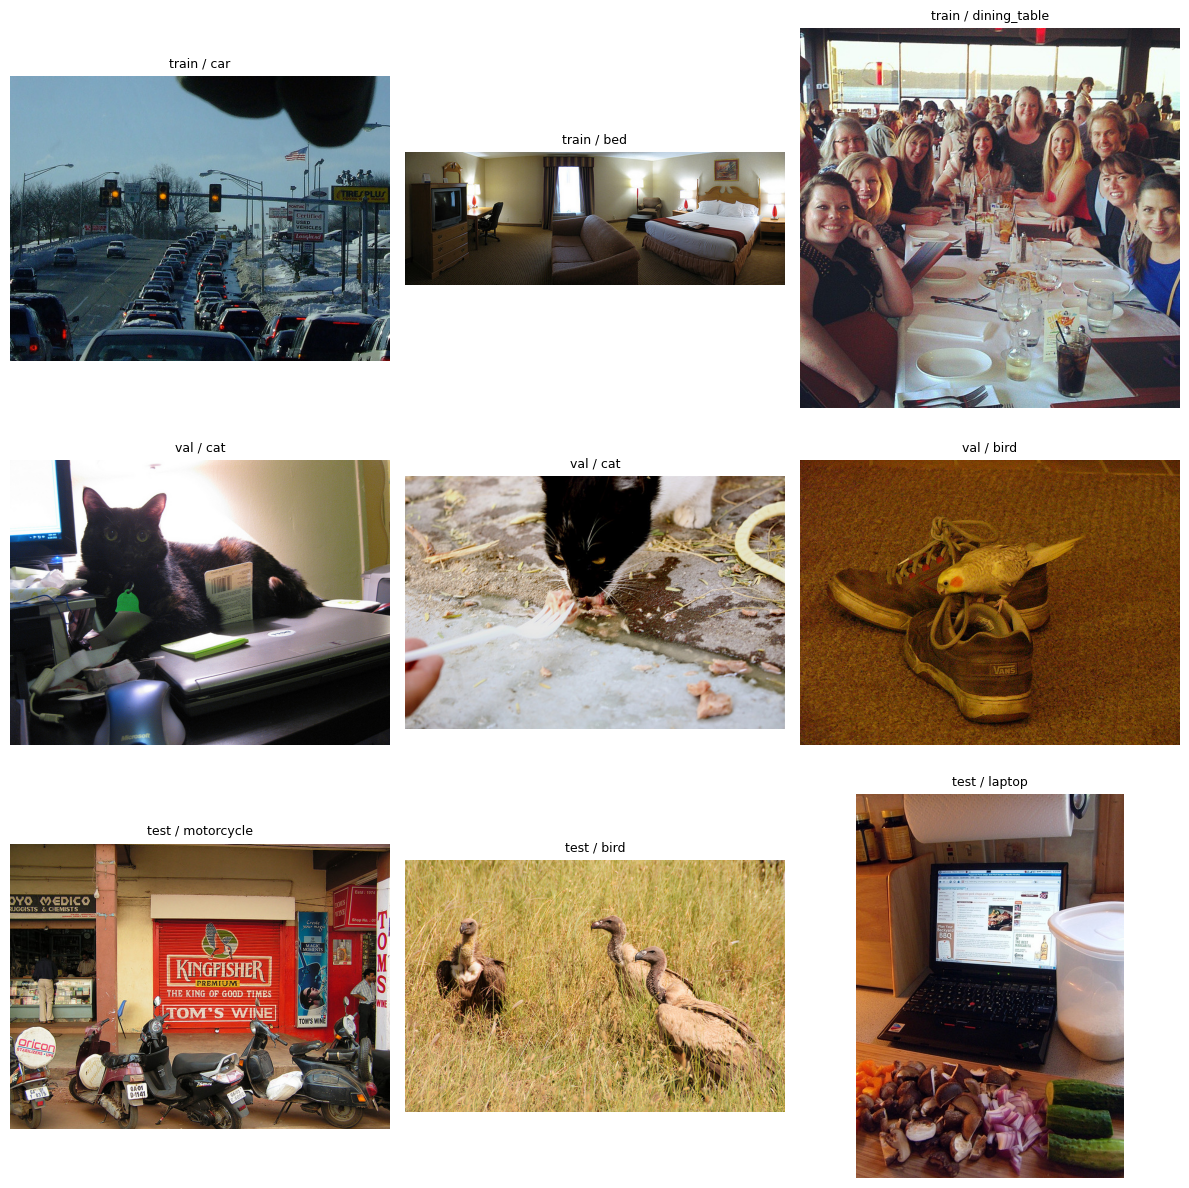


Sample grid displayed: 3 random images per split, titled with split/category.


In [15]:
from PIL import Image

print("non_waste directory validation:")
for split_name in ["train", "val", "test"]:
    split_path = OUTPUT / split_name / "non_waste"
    files = list(split_path.glob("*"))
    print(f"  {split_name}: {len(files)} images at {split_path}")

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
sample_rng = random.Random(42)

for row_idx, split_name in enumerate(["train", "val", "test"]):
    split_path = OUTPUT / split_name / "non_waste"
    files = list(split_path.glob("*"))
    samples = sample_rng.sample(files, min(3, len(files)))

    for col_idx in range(3):
        ax = axes[row_idx, col_idx]
        if col_idx < len(samples):
            img_path = samples[col_idx]
            img = Image.open(img_path)
            ax.imshow(img)
            # Filename pattern: non_waste_{category_slug}_{original_filename}
            parts = img_path.stem.split("_")
            category_guess = "_".join(parts[2:-1]) if len(parts) > 3 else img_path.stem
            ax.set_title(f"{split_name} / {category_guess}", fontsize=9)
        ax.axis("off")

plt.tight_layout()
plt.show()
print("\nSample grid displayed: 3 random images per split, titled with split/category.")